In [28]:
# Libraries
import pandas as pd
import seaborn as sns
import sklearn.cluster as cluster
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [21]:
path = "data/birch3.txt"
df = pd.read_csv(path, sep=" ", header=None, names=["X", "Y"])

## Granularity matters to judge if cluster good or not

<Axes: xlabel='X', ylabel='Y'>

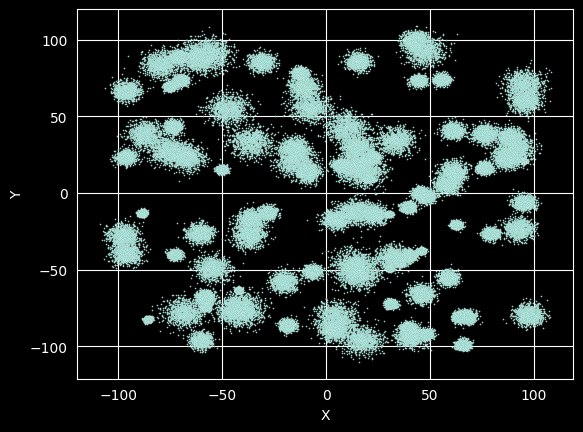

In [22]:
# Highest granularity
sns.scatterplot(df, x="X", y="Y", s=1)

<Axes: xlabel='X', ylabel='Y'>

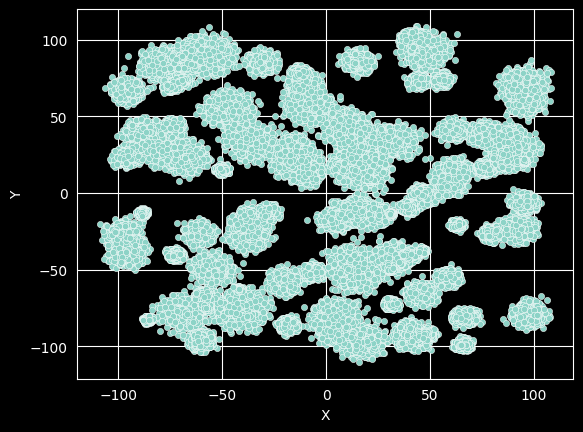

In [23]:
sns.scatterplot(df, x="X", y="Y", s=20)

K-Means
DBScan
Optics
Birch

## Which cluster algorithms to evaluate?


According to https://scikit-learn.org/stable/modules/clustering.html, there
are several clustering algorithms. Below the comment if they work or not:

    * K-Means & variants: We don't have even cluster size, and we have many
    clusters.
    * Affinity propagation: For small datasets, as very complex O(N^2 T).
    N=100K in our case. We get memory error.
    * Mean-shift: Same as for affinity propagation. Not scalable.
    * Spectral Clustering: Designed for small number of clusters. We have
    more like 20-30 clusters here, so not good.
    * Agglomerative Clustering (e.g. Ward): Too computationally heavy.
    Computes distance between all clusters and starts off at every data point
     being one cluster (we have 100k data points). It could work, if we added
      connectivity constraints (maybe s.th. with k-nearest neighbors?). But
      let's continue with the other methods first.
    * DBSCAN / HDBSCAN:
    * OPTICS:
    * Gaussian Mixtures:
    * BIRCH:

## K-Means

In [24]:
# K-Means clustering
n_clust = 30

X = df[['X', 'Y']].values
kmeans = cluster.KMeans(n_clusters=n_clust, random_state=32)
kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

df["Cluster"] = labels
df["Cluster"] = df["Cluster"].astype(str)

In [25]:
#metrics.silhouette_score(df, labels, metric="euclidean")

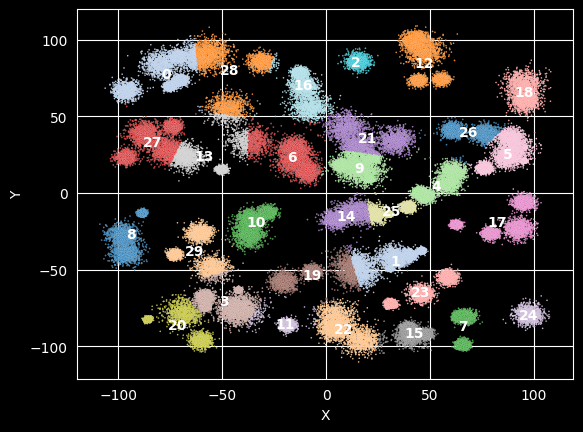

In [26]:
sns.scatterplot(data=df, x='X', y='Y', hue='Cluster', s=1, legend=False,
                palette='tab20')

# Annotate cluster numbers at centroids
for i, (cx, cy) in enumerate(centroids):
    plt.text(
        cx, cy,
        str(i),
        fontsize=10,
        weight='bold',
        ha='center',
        va='center'
    )

Conclusion: Not optimal clustering of the points. Why? Clusters have
different sizes. Many clusters.
K-means good if cluster size even and not too many clusters.

## Playground

In [33]:
# Sample data
sample_df = df.sample(10000, random_state=42)

X_sample = df[['X','Y']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

ward = cluster.AgglomerativeClustering(
    n_clusters=30,
    linkage="ward"
)

labels = ward.fit_predict(X_scaled)

sample_df["Ward_cluster"] = labels

MemoryError: Unable to allocate 37.3 GiB for an array with shape (4999950000,) and data type float64

In [ ]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=df['X'],
    y=df['Y'],
    hue=df['AP_Cluster'],
    palette='tab20',
    s=5,
    legend=False
)

# Get actual centroid coordinates (unscaled)
centroids_scaled = X_scaled[cluster_centers_indices]
centroids = scaler.inverse_transform(centroids_scaled)

# Label clusters at exemplars
for i, (cx, cy) in enumerate(centroids):
    plt.text(
        cx, cy,
        str(i),
        fontsize=10,
        weight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

plt.title(f"Affinity Propagation Clusters ({n_clusters} found)")
plt.show()